In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import nengo

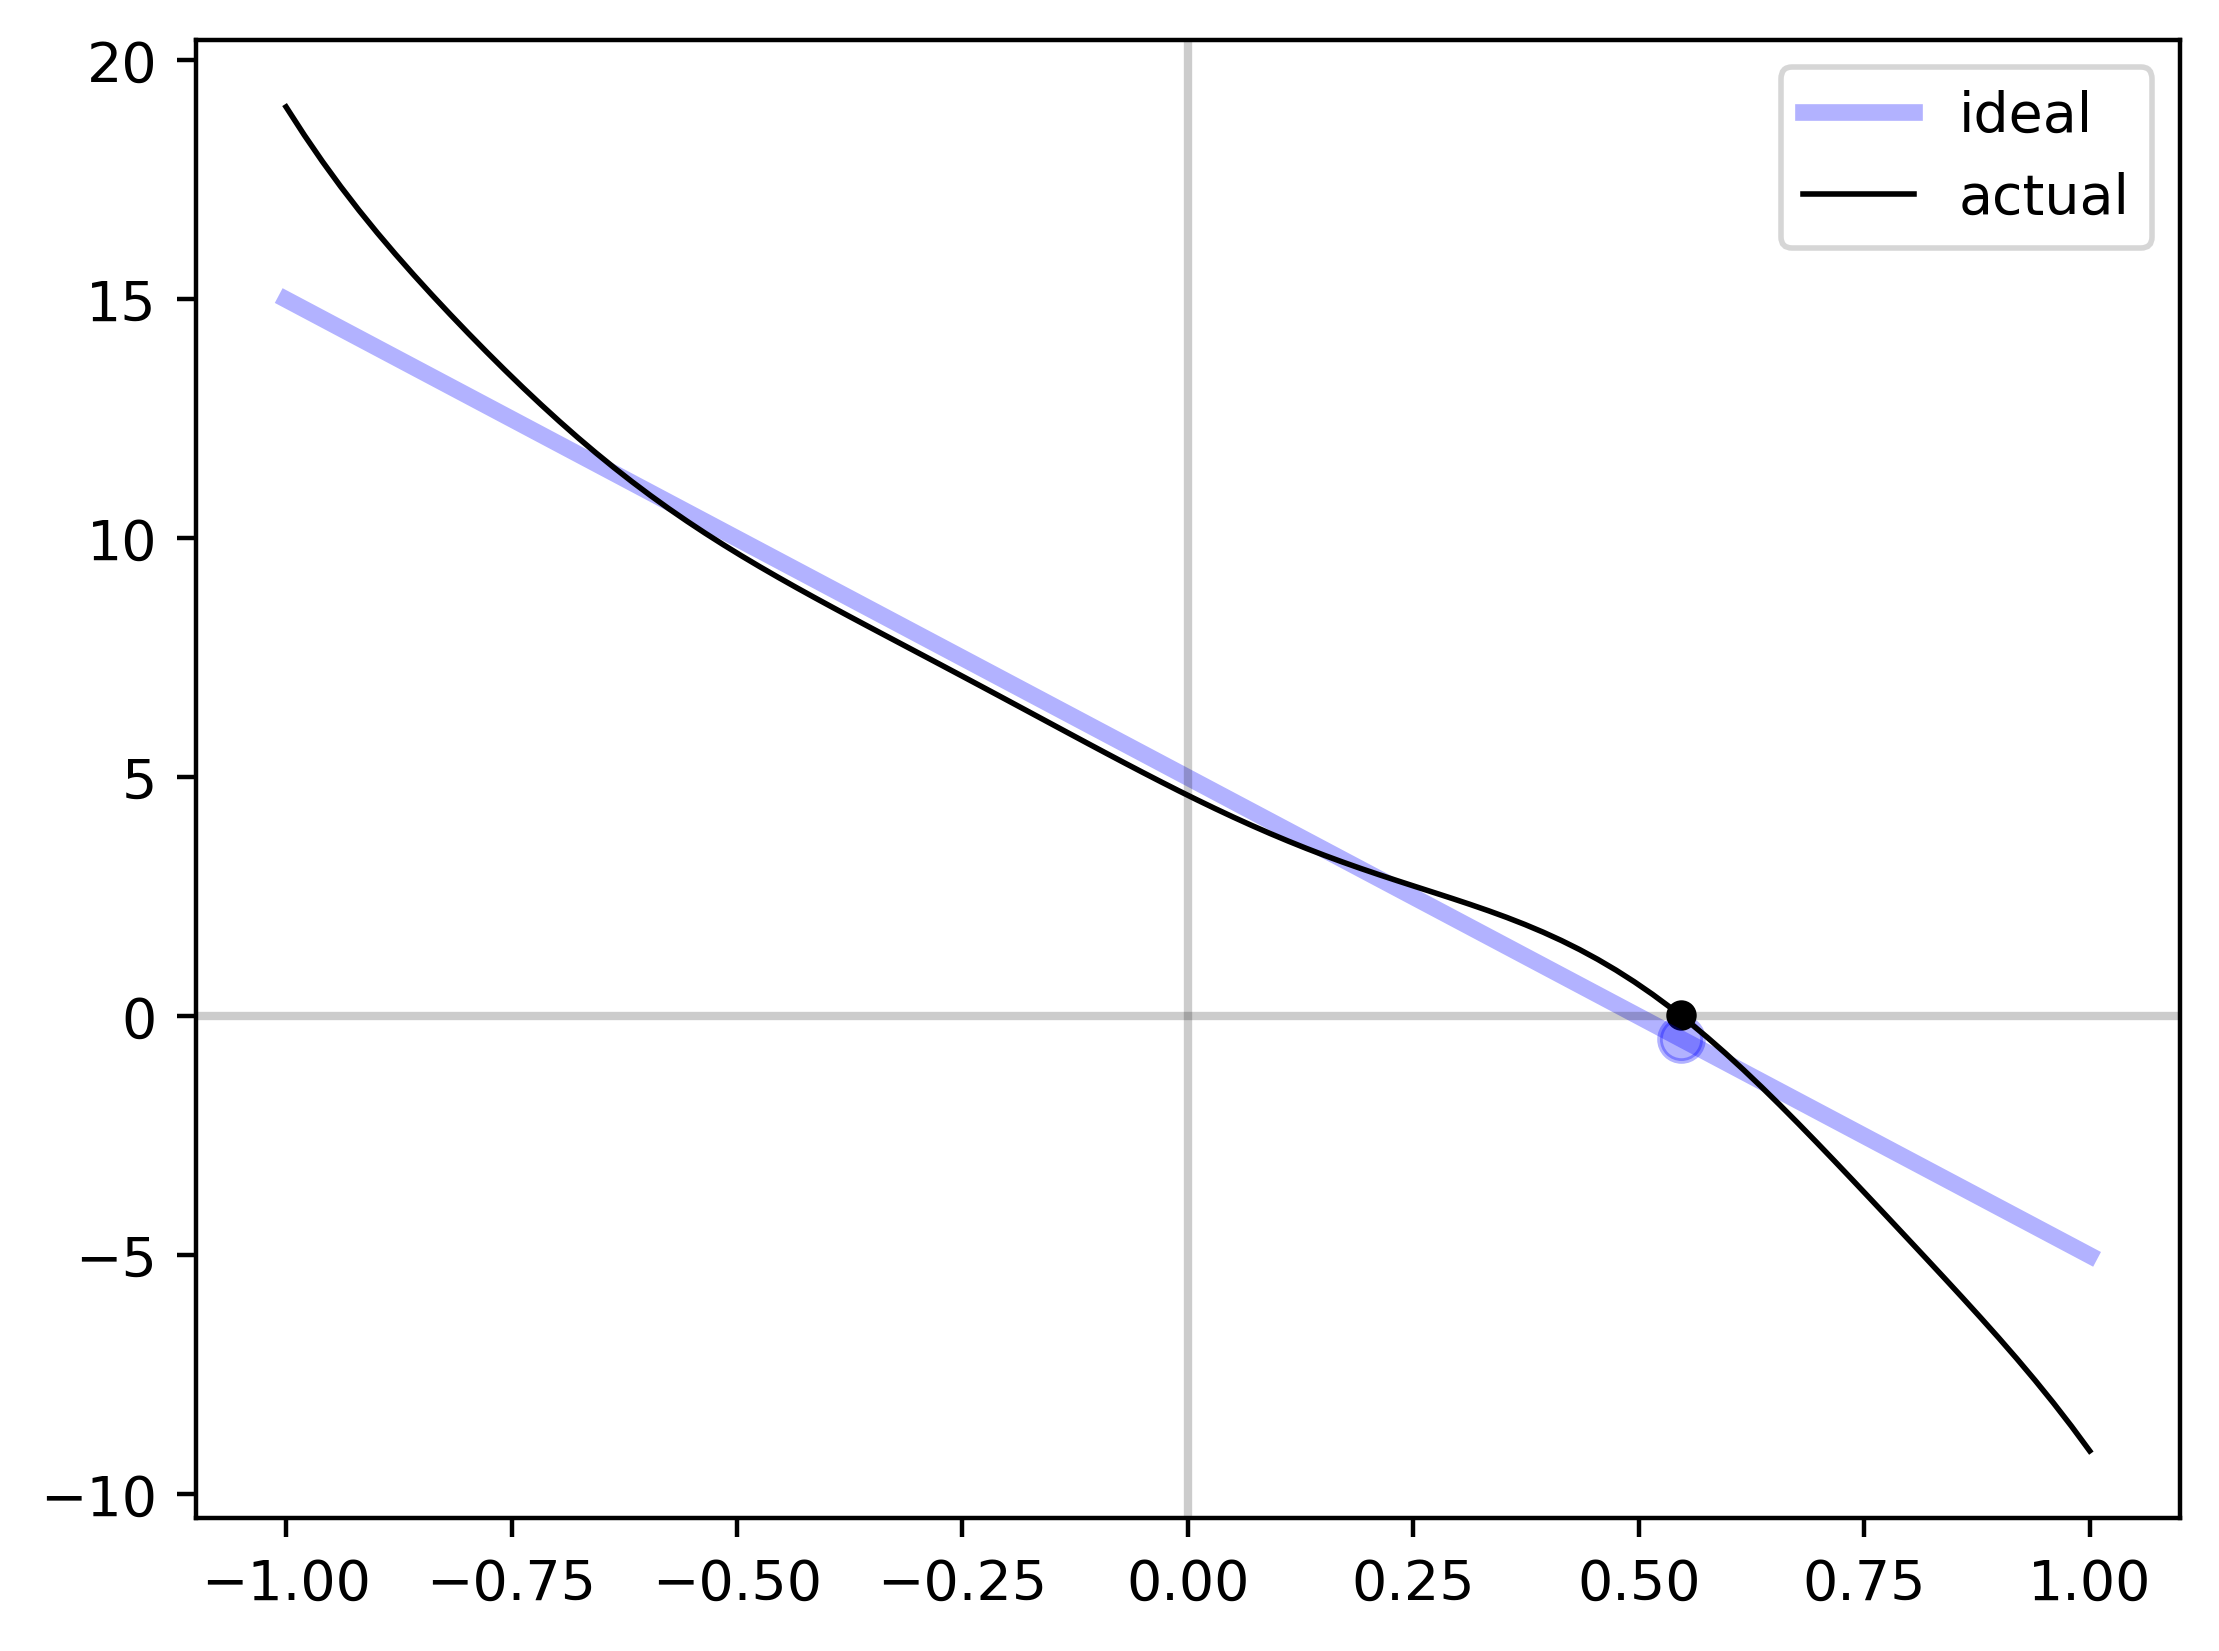

In [2]:
class PhasePortrait(nengo.Process):
    def __init__(self, ensemble, conns_recurrent):
        if isinstance(ensemble, nengo.base.ObjView):
            self.ensemble = ensemble.obj
            self.indices = range(self.ensemble.dimensions)[ensemble.slice]
        else:
            self.ensemble = ensemble
            self.indices = range(self.ensemble.dimensions)
        assert isinstance(self.ensemble, nengo.Ensemble)
        
        self.conns_recurrent = conns_recurrent
            
        super().__init__(default_size_in=self.ensemble.dimensions*2,
                         default_size_out=0)
    
    def make_state(self, shape_in, shape_out, dt, dtype=None, y0=0):
        return {'u': np.zeros(self.ensemble.dimensions), 'x':np.zeros(self.ensemble.dimensions)}
    
    def make_step(self, shape_in, shape_out, dt, rng, state):
        
        def step_phase_portrait(t, x, state=state):
            state['u'][:] = x[:self.ensemble.dimensions]
            state['x'][:] = x[self.ensemble.dimensions:]
            
        return step_phase_portrait
        
        
    @staticmethod
    def create(ensemble, network):
        if isinstance(ensemble, nengo.base.ObjView):
            ensemble_obj = ensemble.obj
        else:
            ensemble_obj = ensemble
        conns_forward = []
        conns_recurrent = []
        for conn in network.all_connections:
            if conn.post_obj is ensemble_obj:
                assert isinstance(conn.synapse, nengo.synapses.Lowpass)
                conns = conns_forward if conn.pre_obj is not ensemble_obj else conns_recurrent
                conns.append(conn)
        
        node = nengo.Node(PhasePortrait(ensemble, conns_recurrent))
        
        for conn in conns_forward:
            nengo.Connection(conn.pre, node[range(ensemble_obj.dimensions)[conn.post_slice]], 
                             function=conn.function, 
                             transform=conn.transform.init/conn.synapse.tau,
                             synapse=None)
        for conn in conns_forward + conns_recurrent:
            nengo.Connection(conn.pre, node[range(ensemble_obj.dimensions,2*ensemble_obj.dimensions)[conn.post_slice]], 
                             function=conn.function, 
                             transform=conn.transform,
                             synapse=conn.synapse)
        return node
    
    def compute_portrait(self, sim, domain=np.array([np.linspace(-1, 1, 100)])):
        for op in sim.model.operators:
            if isinstance(op, nengo.builder.processes.SimProcess):
                if op.process is self:
                    sig_u = op.state['u']    
                    sig_x = op.state['x']
        u = sim.signals[sig_u]
        x = sim.signals[sig_x]
        
        
        dec = np.zeros((self.ensemble.dimensions, self.ensemble.n_neurons))
        
        domain = np.vstack([domain.T, [x[self.indices]]]).T
        
        dx_total = np.zeros_like(domain)
        for conn in self.conns_recurrent:
            if conn.function is None:
                dx = domain
            else:
                dx = np.array(conn.function(domain))
            if not isinstance(conn.transform, nengo.transforms.NoTransform):
                dx = np.dot(dx, conn.transform.init)
            dx_total += dx/conn.synapse.tau
            
            w = sim.data[conn].weights
            w = w/conn.synapse.tau
            
            dec[conn.post_slice,:] += w
            
        pts = np.zeros((self.ensemble.dimensions, domain.shape[1]), dtype=float)
        pts[self.indices,:] = domain
        
        _, a = nengo.utils.ensemble.tuning_curves(self.ensemble, sim, pts.T)
        v = a @ dec.T
        
        v = v[:,self.indices].T
            
        # TODO: what happens with multiple different synapses?!???
        dx_total -=domain/conn.synapse.tau
        v -= domain/conn.synapse.tau
        
        ideal = dx_total+u[self.indices,None]
        actual = v+u[self.indices,None]
        
        
        return dict(domain=domain[:,:-1], ideal=ideal[:,:-1], actual=actual[:,:-1], x=domain[:,-1], ideal_now=ideal[:,-1], actual_now=actual[:,-1])
        
                    
model = nengo.Network(seed=1)
with model:
    stim = nengo.Node(0.5)
    ens = nengo.Ensemble(n_neurons=30, dimensions=2, neuron_type=nengo.Tanh())
    tau_desired = 0.1
    tau_synapse = 0.01
    nengo.Connection(stim, ens[0], transform=tau_synapse/tau_desired, synapse=tau_synapse)
    #nengo.Connection(ens, ens, transform=1-tau_synapse/tau_desired, synapse=tau_synapse)
    nengo.Connection(ens, ens, transform=1, synapse=tau_synapse)
    nengo.Connection(ens, ens, transform=-tau_synapse/tau_desired, synapse=tau_synapse)
    nengo.Connection(ens, ens, transform=0, synapse=tau_synapse)
    
    phase1 = PhasePortrait.create(ens[0], model)
    phase2 = PhasePortrait.create(ens, model)
        
sim = nengo.Simulator(model, progress_bar=False)
with sim:
    sim.run(0.5)
    
    portrait1=phase1.output.compute_portrait(sim, domain=np.array([np.linspace(-1, 1, 100)]))
    portrait2=phase2.output.compute_portrait(sim, domain=np.array(np.meshgrid(np.linspace(-1, 1, 20), np.linspace(-1, 1, 20))).reshape(2,-1))
    
plt.figure(dpi=400)
plt.plot(portrait1['domain'][0], portrait1['ideal'][0], label='ideal', lw=3, alpha=0.3, c='b')
plt.plot(portrait1['domain'][0], portrait1['actual'][0], label='actual', lw=1, c='k')

plt.scatter([portrait1['x']], portrait1['ideal_now'], alpha=0.3, c='b', s=60)
plt.scatter([portrait1['x']], portrait1['actual_now'], alpha=1, c='k', s=20)

plt.axhline(0, alpha=0.2, c='k')
plt.axvline(0, alpha=0.2, c='k')
plt.legend()
plt.show()


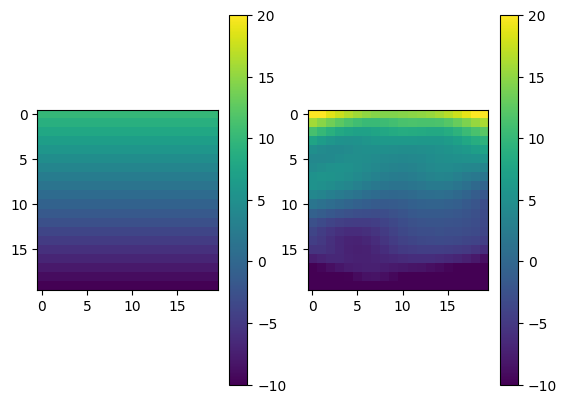

In [3]:
ideal = portrait2['ideal'].reshape(2, 20, 20)
actual = portrait2['actual'].reshape(2, 20, 20)

plt.subplot(1, 2, 1)
plt.imshow(ideal[1], vmin=-10, vmax=20)
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(actual[1], vmin=-10, vmax=20)
plt.colorbar()

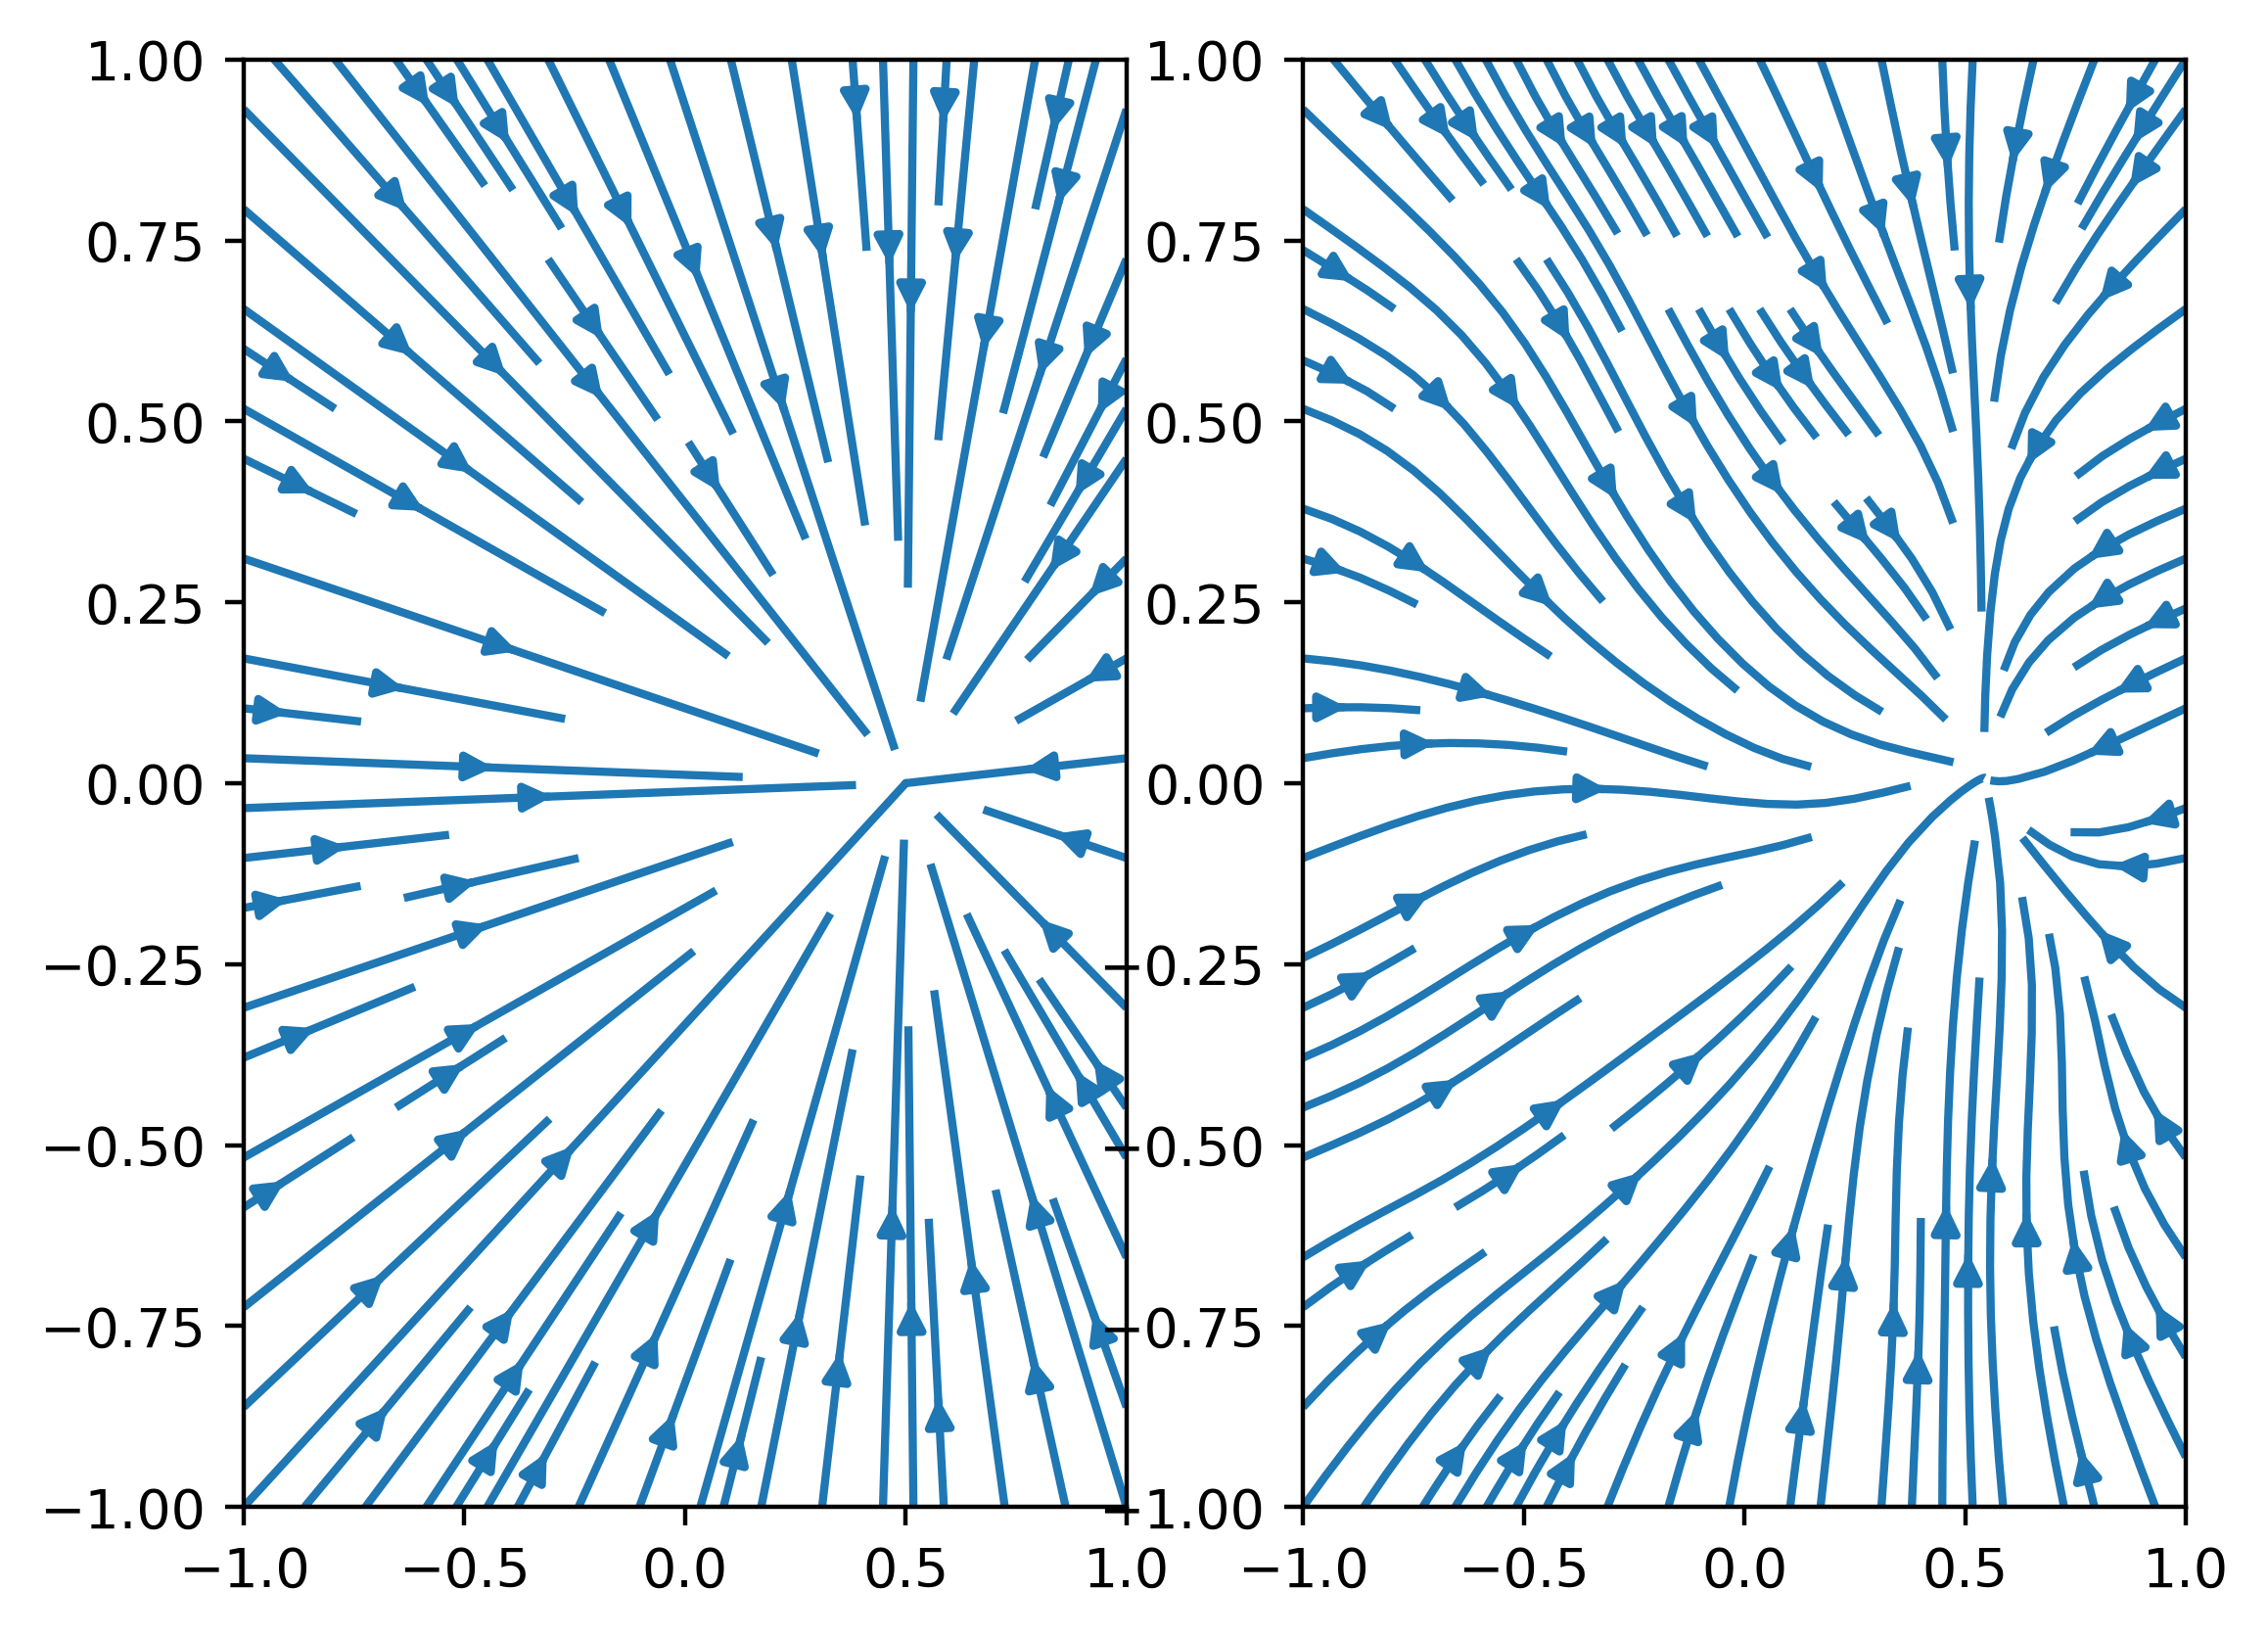

In [4]:
plt.figure(dpi=400)

plt.subplot(1, 2, 1)
plt.streamplot(np.linspace(-1, 1, 20), np.linspace(-1, 1, 20), ideal[0], ideal[1])
plt.subplot(1, 2, 2)
plt.streamplot(np.linspace(-1, 1, 20), np.linspace(-1, 1, 20), actual[0], actual[1])


In [5]:
model = nengo.Network(seed=1)
with model:
    ens = nengo.Ensemble(n_neurons=5, dimensions=2, neuron_type=nengo.Tanh())
    
    synapse = 0.1
    def oscillator(x):
        r = 1
        gamma = 3
        s = 6
        return [
            synapse * (-x[1] * s + gamma*x[0] * (r - x[0] ** 2 - x[1] ** 2)) + x[0],
            synapse * (x[0] * s + gamma*x[1] * (r - x[0] ** 2 - x[1] ** 2)) + x[1],
        ]
    
    nengo.Connection(ens, ens, synapse=synapse, function=oscillator)    

    phase = PhasePortrait.create(ens, model)
        
sim = nengo.Simulator(model, progress_bar=False)
with sim:
    sim.run(0.5)
    
    portrait=phase.output.compute_portrait(sim, domain=np.array(np.meshgrid(np.linspace(-1, 1, 20), np.linspace(-1, 1, 20))).reshape(2,-1))


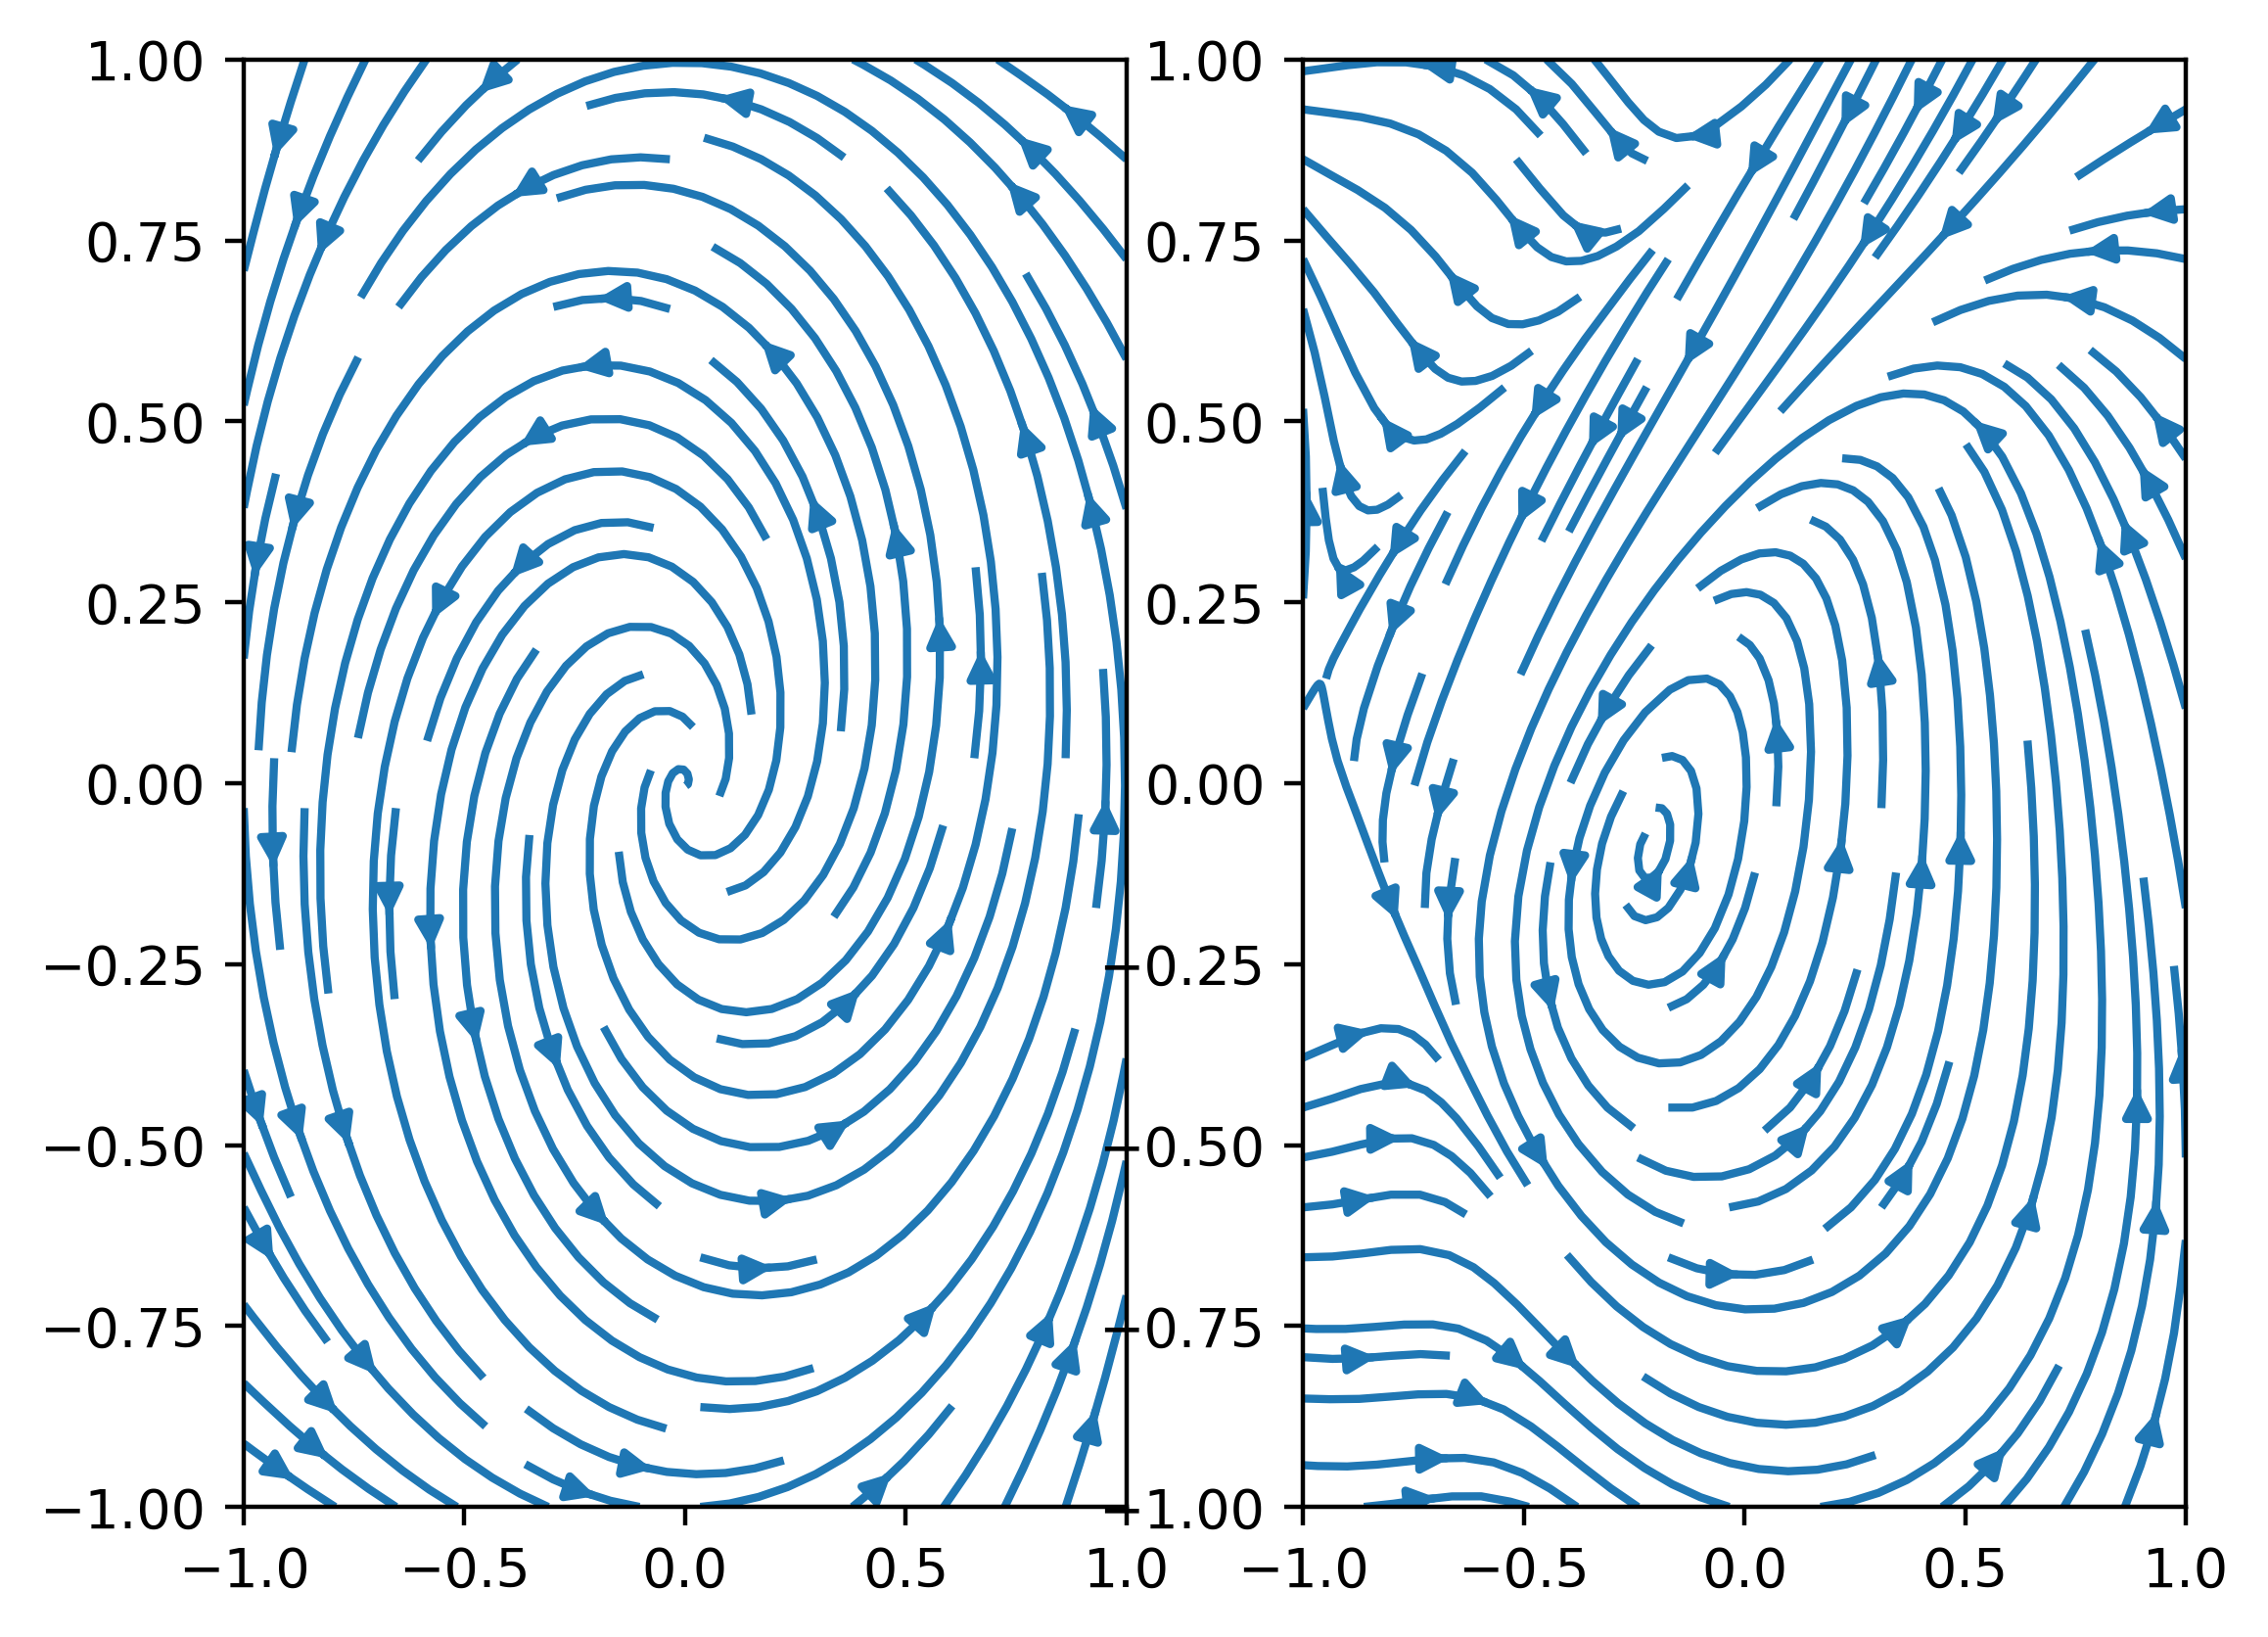

In [6]:
plt.figure(dpi=400)

ideal = portrait['ideal'].reshape(2, 20, 20)
actual = portrait['actual'].reshape(2, 20, 20)


plt.subplot(1, 2, 1)
plt.streamplot(np.linspace(-1, 1, 20), np.linspace(-1, 1, 20), ideal[0], ideal[1])
plt.subplot(1, 2, 2)
plt.streamplot(np.linspace(-1, 1, 20), np.linspace(-1, 1, 20), actual[0], actual[1])


import io
f = io.BytesIO()
plt.savefig(f, format = "svg")


In [7]:
portrait['x']

array([-0.4015596, -0.1483487])

In [8]:
import matplotlib.pyplot as plt

In [9]:
model = nengo.Network(seed=1)
with model:
    ens = nengo.Ensemble(n_neurons=50, dimensions=2, neuron_type=nengo.Tanh())
    
    synapse = 0.1
    def oscillator(x):
        r = 1
        gamma = 3
        s = 6
        return [
            synapse * (-x[1] * s + gamma*x[0] * (r - x[0] ** 2 - x[1] ** 2)) + x[0],
            synapse * (x[0] * s + gamma*x[1] * (r - x[0] ** 2 - x[1] ** 2)) + x[1],
        ]
    
    nengo.Connection(ens, ens, synapse=synapse, function=oscillator)    

    phase = PhasePortrait.create(ens, model)
    
    def make_plot(t):
        return
    make_plot._nengo_html_ = 'test'
    plot = nengo.Node(make_plot)
    
    
    
def on_step(sim):
    if sim.n_steps % 100 != 0:
        return
    portrait=phase.output.compute_portrait(sim, domain=np.array(np.meshgrid(np.linspace(-1, 1, 20), np.linspace(-1, 1, 20))).reshape(2,-1))

    ideal = portrait['ideal'].reshape(2, 20, 20)
    actual = portrait['actual'].reshape(2, 20, 20)

    #plt.plot([0,1],[0,1])
    #plt.streamplot(np.linspace(-1, 1, 20), np.linspace(-1, 1, 20), ideal[0], ideal[1])
    plt.figure()
    plt.streamplot(np.linspace(-1, 1, 20), np.linspace(-1, 1, 20), actual[0], actual[1])
    plt.scatter([portrait['x'][0]], portrait['x'][1], alpha=1, c='k', s=50)

    
    import io
    f = io.BytesIO()
    plt.savefig(f, format = "svg")
    make_plot._nengo_html_ = f.getvalue().decode("utf-8")
    plt.close()
    
    


In [10]:
import nengo_gui.jupyter
nengo_gui.jupyter.InlineGUI(model, cfg='layout.cfg')

In [11]:
sim

In [9]:
model = nengo.Network(seed=1)
with model:
    ens = nengo.Ensemble(n_neurons=100, dimensions=3, neuron_type=nengo.Tanh(), radius=1.5)
    
    synapse = 0.1
    def oscillator(x):
        r = 1
        gamma = 3
        s = 6 * x[2]
        return [
            synapse * (-x[1] * s + gamma*x[0] * (r - x[0] ** 2 - x[1] ** 2)) + x[0],
            synapse * (x[0] * s + gamma*x[1] * (r - x[0] ** 2 - x[1] ** 2)) + x[1],
            0
        ]
    
    nengo.Connection(ens, ens, synapse=synapse, function=oscillator)    

    spd = nengo.Node(1)
    nengo.Connection(spd, ens[2], transform=1)
    
    
    phase = PhasePortrait.create(ens, model)
    
    def make_plot(t):
        return
    make_plot._nengo_html_ = 'test'
    plot = nengo.Node(make_plot)
    
    
    
def on_step(sim):
    if sim.n_steps % 100 != 0:
        return
    portrait=phase.output.compute_portrait(sim, domain=np.array(np.meshgrid(np.linspace(-1, 1, 20), np.linspace(-1, 1, 20))).reshape(2,-1))

    ideal = portrait['ideal'].reshape(2, 20, 20)
    actual = portrait['actual'].reshape(2, 20, 20)

    #plt.plot([0,1],[0,1])
    #plt.streamplot(np.linspace(-1, 1, 20), np.linspace(-1, 1, 20), ideal[0], ideal[1])
    plt.figure()
    plt.streamplot(np.linspace(-1, 1, 20), np.linspace(-1, 1, 20), actual[0], actual[1])
    plt.scatter([portrait['x'][0]], portrait['x'][1], alpha=1, c='k', s=50)

    
    import io
    f = io.BytesIO()
    plt.savefig(f, format = "svg")
    make_plot._nengo_html_ = f.getvalue().decode("utf-8")
    plt.close()
    
    


In [10]:
import nengo_gui.jupyter
nengo_gui.jupyter.InlineGUI(model, cfg='layout.cfg')